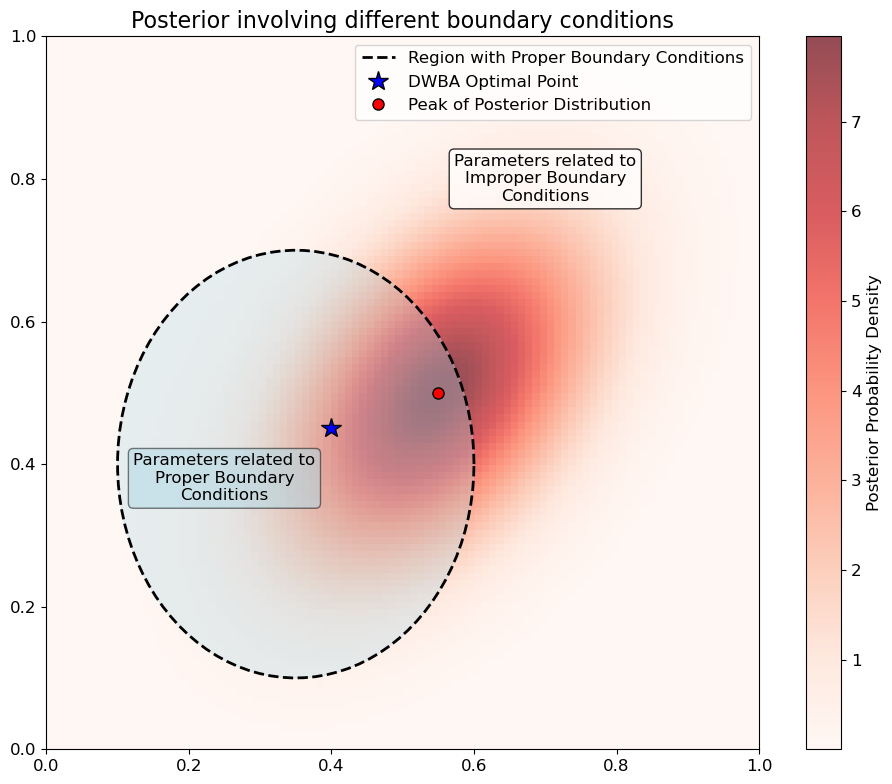

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 1. 创建参数空间网格
p1, p2 = np.mgrid[0:1:100j, 0:1:100j]
pos = np.dstack((p1, p2))

# 2. 定义"满足边界条件的参数区域" (一个椭圆)
bc_center = [0.35, 0.4]
bc_width, bc_height = 0.25, 0.3

# 3. 定义贝叶斯后验分布
posterior_center = [0.55, 0.5]
covariance = [[0.02, 0.01], [0.01, 0.025]]
posterior_rv = multivariate_normal(posterior_center, covariance)
posterior_pdf = posterior_rv.pdf(pos)

# 4. 定义传统方法的最优解
traditional_point = [0.4, 0.45]

# 5. 开始绘图
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# 使用 pcolormesh 绘制后验概率热图
im = ax.pcolormesh(p1, p2, posterior_pdf, cmap='Reds', alpha=0.7, shading='auto')
plt.colorbar(im, ax=ax, label='Posterior Probability Density')

# 绘制边界条件区域
theta = np.linspace(0, 2*np.pi, 100)
ellipse_x = bc_center[0] + bc_width * np.cos(theta)
ellipse_y = bc_center[1] + bc_height * np.sin(theta)
ax.plot(ellipse_x, ellipse_y, 'k--', linewidth=2, label='Region with Proper Boundary Conditions')
ax.fill(ellipse_x, ellipse_y, color='lightblue', alpha=0.3)

# 标记点
ax.plot(traditional_point[0], traditional_point[1], 'b*', markersize=15, 
        markeredgecolor='black', label='DWBA Optimal Point')
ax.plot(posterior_center[0], posterior_center[1], 'ro', markersize=8, 
        markeredgecolor='black', label='Peak of Posterior Distribution')

# 标注区域
ax.text(0.7, 0.8, 'Parameters related to\nImproper Boundary\nConditions', ha='center', va='center', 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.text(0.25, 0.38, 'Parameters related to\nProper Boundary\nConditions', ha='center', va='center', 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

# 设置图形属性
ax.set_xlabel('Some parameter', fontsize=14)
ax.set_ylabel('Some parameter', fontsize=14)
plt.title('Posterior involving different boundary conditions', fontsize=16)
ax.legend(loc='upper right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('schematic1.pdf', dpi=300)
plt.show()